<div align="center">

# UNIVERSIDAD NACIONAL AUTÓNOMA DE MÉXICO
## FACULTAD DE CIENCIAS
### DIPLOMADO MACHINE LEARNING EN SEGUROS

**Módulo 3:** Machine Learning
**Tema 1:** Introducción a Machine Learning
**Parte 2**

---

</div>

### EQUIPO

**Integrantes:**
* Benitez Mota Ricardo Antonio
* Castillo Dorantes Sandra Geraldine
* López Cervantes Karla Itzel
* Mendoza Pérez Cnidia
* Moctezuma Santana Sergio Alfonso
* Saldaña Herver Miriam Itzel

<br>

---

<div align="center">

**Profesor:** Eduardo Bello Castañeda

**Fecha de entrega:** CDMX, a 12 de julio de 2026

</div>

## Análisis exploratorio y modelos predictivos sobre cartera de seguros

**Base:** `cartera_q1_2026_final.parquet`  
**Ramo seleccionado:** `GMM` — Gastos Médicos Mayores  


## 1. Carga de librerías

In [29]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor


from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid")

## 2. Lectura de la base

In [2]:
ruta_parquet = Path.cwd() / "cartera_q1_2026_final.parquet" # Misma carpeta donde esta el script
#Path("C:/Users/karly/OneDrive/Documents/Diplomado/diplomado-ml-Karla-Itzel-Lopez-Cervantes/modulo3/cartera_q1_2026_final.parquet")

df = pd.read_parquet(ruta_parquet)

df.head()

,id_poliza,num_poliza,nombre,apellido_paterno,apellido_materno,rfc,edad,sexo,estado_civil,ocupacion,...,comision_est,nivel_riesgo,anio_emision,mes_emision,trimestre,segmento_prima_fijo,cuartil_prima,cod_ramo,anio_poliza,ramo_desde_codigo
0,POL-000001,Vid-21-000001,Gabriela,Moreno,Vega,MOGV020429CG6,24,F,Union libre,Independiente,...,"5,892.42",BAJO,2021,11,4,Premium,Q4,VID,2021,Vida
1,POL-000002,Aut-19-000002,Valeria,Torres,Castillo,TOVC020815IA8,23,F,Casado,Contador,...,882.44,BAJO,2019,8,3,Alta,Q1,AUT,2019,Autos
2,POL-000003,GMM-22-000003,Fernanda,Ramos,Silva,RAFS941018BC1,31,M,Union libre,Ingeniero,...,"1,995.46",BAJO,2022,7,3,Premium,Q3,GMM,2022,GMM
3,POL-000004,Vid-19-000004,Silvia,Mendoza,Gutierrez,MESG860204IH8,40,M,Soltero,Arquitecto,...,"14,002.67",BAJO,2019,3,1,Premium,Q4,VID,2019,Vida
4,POL-000005,Vid-20-000005,Antonio,Ramos,Castillo,RAAC960722ME2,29,F,Soltero,Independiente,...,"6,545.88",MEDIO,2020,11,4,Premium,Q4,VID,2020,Vida


### Revisión inicial de la base

Antes de seleccionar el ramo, revisamos el tamaño de la base y las columnas disponibles. Esto nos ayuda a tener una primera idea de qué tan completa está la información y qué variables pueden servir para nuestrp análisis actuarial.

In [3]:
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]:,}")

df.info()

Filas: 50,000
Columnas: 52
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 52 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id_poliza              50000 non-null  object        
 1   num_poliza             50000 non-null  object        
 2   nombre                 50000 non-null  category      
 3   apellido_paterno       50000 non-null  category      
 4   apellido_materno       50000 non-null  category      
 5   rfc                    50000 non-null  object        
 6   edad                   50000 non-null  int8          
 7   sexo                   50000 non-null  category      
 8   estado_civil           50000 non-null  category      
 9   ocupacion              46000 non-null  category      
 10  ramo                   50000 non-null  category      
 11  plan                   50000 non-null  category      
 12  fecha_emision          50000 non-

## 3. Selección del ramo

Para elegir el ramo, primero revisamos cuántos registros hay en cada uno. Un ramo con más observaciones nos da una base más estable para comparar distribuciones, detectar valores extremos y entrenar modelos.

In [4]:
conteo_ramos = (
    df["ramo"]
    .value_counts()
    .rename_axis("ramo")
    .reset_index(name="registros")
)

conteo_ramos["porcentaje %"] = (
    (conteo_ramos["registros"] / len(df) * 100)
    .round(2)
    .astype(str) + "%"
)

conteo_ramos

,ramo,registros,porcentaje %
0,GMM,22531,45.06%
1,Autos,14752,29.5%
2,Vida,7510,15.02%
3,Accidentes Personales,5207,10.41%


### Interpretación del conteo por ramo

El ramo con mayor número de registros es **GMM**, con  **45.06%** de la cartera total. Por esa razón lo seleccionamos para nuestro análisis.

Por un lado, podemos estudiar cuántos asegurados presentan siniestros y, por otro, analizar qué tan grandes llegan a ser los montos pagados cuando estos ocurren. Este comportamiento es relevante porque normalmente muchos asegurados pueden no generar reclamaciones durante cierto periodo, mientras que algunos pocos casos pueden representar costos mucho más elevados para la aseguradora.

Por esto, trabajar con este ramo nos permit+ira realizar un análisis más completo, ya que podemos revisar patrones en los datos, identificar comportamientos fuera de lo común y aplicar modelos que ayuden a entender mejor cómo se comporta el riesgo

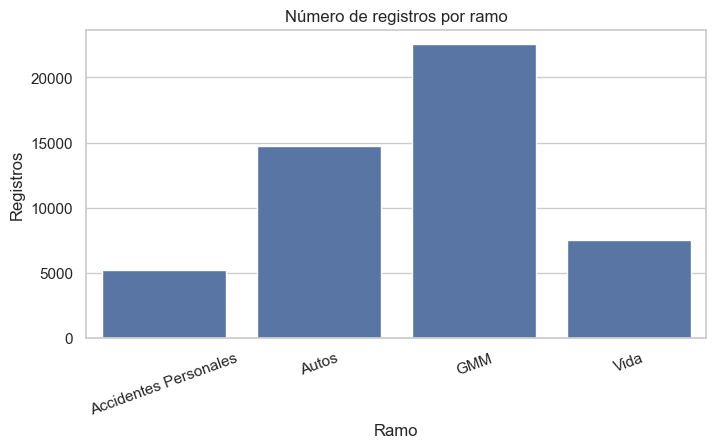

In [5]:
plt.figure(figsize=(8, 4))
sns.barplot(data=conteo_ramos, x="ramo", y="registros")
plt.title("Número de registros por ramo")
plt.xlabel("Ramo")
plt.ylabel("Registros")
plt.xticks(rotation=20)
plt.show()

### Interpretación de la gráfica de ramos

La gráfica confirma que **GMM** es el ramo con más observaciones dentro de la base. Esto hace que sea una buena elección para el análosos, ya que permite trabajar con una muestra amplia y reduce un poco el riesgo de sacar conclusiones a partir de pocos datos.

In [6]:
df_gmm = df[df["ramo"] == "GMM"].copy()

print(f"Registros de GMM: {len(df_gmm):,}")
df_gmm.head()

Registros de GMM: 22,531


,id_poliza,num_poliza,nombre,apellido_paterno,apellido_materno,rfc,edad,sexo,estado_civil,ocupacion,...,comision_est,nivel_riesgo,anio_emision,mes_emision,trimestre,segmento_prima_fijo,cuartil_prima,cod_ramo,anio_poliza,ramo_desde_codigo
2,POL-000003,GMM-22-000003,Fernanda,Ramos,Silva,RAFS941018BC1,31,M,Union libre,Ingeniero,...,"1,995.46",BAJO,2022,7,3,Premium,Q3,GMM,2022,GMM
6,POL-000007,GMM-23-000007,Mario,Reyes,Castillo,REMC680423LH5,58,M,Divorciado,Jubilado,...,"2,236.32",BAJO,2023,3,1,Premium,Q3,GMM,2023,GMM
7,POL-000008,GMM-19-000008,Carlos,Rivera,Sanchez,RICS710805YY4,54,M,Casado,Director,...,629.66,BAJO,2019,3,1,Alta,Q1,GMM,2019,GMM
8,POL-000009,GMM-24-000009,Jose,Nunez,Reyes,NUJR930612XL7,32,M,Union libre,Empresario,...,"10,879.18",BAJO,2024,11,4,Premium,Q4,GMM,2024,GMM
10,POL-000011,GMM-23-000011,Daniel,Ortiz,Martinez,ORDM850718BP5,40,F,Union libre,Analista,...,"1,888.48",MEDIO,2023,5,2,Premium,Q3,GMM,2023,GMM


## 4. Preparación de variables

Se crean algunas variables auxiliares para facilitar el análisis:

- `siniestro_positivo`: identifica si la póliza tuvo al menos un siniestro.
- `monto_pagado_log`: transformación logarítmica del monto pagado para suavizar el efecto de pagos muy grandes.

In [7]:
df_gmm["siniestro_positivo"] = np.where(df_gmm["n_siniestros"].fillna(0) > 0, 1, 0)
df_gmm["monto_pagado_log"] = np.log1p(df_gmm["monto_pagado"].fillna(0))

df_gmm[["n_siniestros", "siniestro_positivo", "monto_pagado", "monto_pagado_log"]].head()

,n_siniestros,siniestro_positivo,monto_pagado,monto_pagado_log
2,0.00,0,0.00,0.00
6,0.00,0,0.00,0.00
7,0.00,0,0.00,0.00
8,0.00,0,0.00,0.00
10,1.00,1,"7,655.00",8.94


### Interpretación de las variables creadas

La variable `siniestro_positivo` ayuda a separar las pólizas que sí tuvieron a siniestros de las que no tuvieron.

La transformación logarítmica del monto pagado lo usaremos porque los montos de siniestros suelen tener mucha concentración en cero o valores bajos, pero también pueden tener casos muy altos. Con el logaritmo, esos casos extremos siguen estando presentes, pero ya no dominaran tanto el análisis visual y de los modelos.

## 5. Estadísticas descriptivas

A continuación revisaremos algunas variables numéricas importantes del ramo GMM. En donde incluiremos variables de exposición, prima, suma asegurada, deducible y siniestralidad.

In [8]:
variables_numericas = [
    "edad", "prima_total", "suma_asegurada", "deducible",
    "n_siniestros", "monto_reclamado", "monto_pagado", "loss_ratio"
]

resumen_descriptivo = df_gmm[variables_numericas].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).T

resumen_descriptivo = resumen_descriptivo.rename(
    columns={"50%": "mediana"}
)

resumen_descriptivo.style.format("{:,.2f}") \
    .set_caption("Resumen estadístico de variables numéricas - GMM") \
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "16px"),
                ("font-weight", "bold"),
                ("text-align", "center")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("font-weight", "bold"),
                ("text-align", "center")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("text-align", "center")
            ]
        }
    ])

,count,mean,std,min,25%,mediana,75%,90%,95%,99%,max
edad,"22,531.00",43.30,12.97,21.00,32.00,43.00,54.00,61.00,64.00,65.00,66.00
prima_total,"22,531.00","32,445.18","28,387.43","5,104.00","9,493.44","22,049.28","52,571.20","80,388.00","91,366.70","106,062.40","114,931.87"
suma_asegurada,"22,531.00","1,106,999.25","951,412.30","200,000.00","300,000.00","800,000.00","2,000,000.00","3,000,000.00","3,000,000.00","3,000,000.00","3,000,000.00"
deducible,"22,531.00","11,623.54","5,319.32","5,000.00","8,000.00","10,000.00","15,000.00","20,000.00","20,000.00","20,000.00","20,000.00"
n_siniestros,"22,531.00",0.36,0.60,0.00,0.00,0.00,1.00,1.00,2.00,2.00,4.00
monto_reclamado,"22,531.00","13,403.79","37,203.45",0.00,0.00,0.00,"10,300.81","42,182.04","72,690.33","164,773.87","947,321.62"
monto_pagado,"22,531.00","4,301.29","20,609.64",0.00,0.00,0.00,0.00,"6,533.45","25,728.04","89,721.74","698,744.32"
loss_ratio,"22,531.00",0.20,0.80,0.00,0.00,0.00,0.00,0.21,1.31,5.00,5.00


### Interpretación de las estadísticas descriptivas

La edad se mueve dentro de un rango amplio de asegurados adultos, mientras que la prima, la suma asegurada y el deducible muestran distintos niveles de concentración.

Lo más importante está en la parte de siniestros: la mediana de `monto_pagado` es **0**, lo que significa que al menos la mitad de las pólizas no tuvo pago de siniestro en el periodo observado. Sin embargo, el percentil 99 del monto pagado es cercano a **89,72**, y el máximo llega a un valor mucho más alto. Esto muestra que aunque la mayoría de los casos no genera pagos, sí existen eventos grandes que pueden afectar bastante la cartera.

## 6. Distribuciones de variables principales

Graficamos seis variables que ayudan a entender la cartera desde: características de los asegurados, condiciones de sus pólizas y comportamiento de los siniestros.

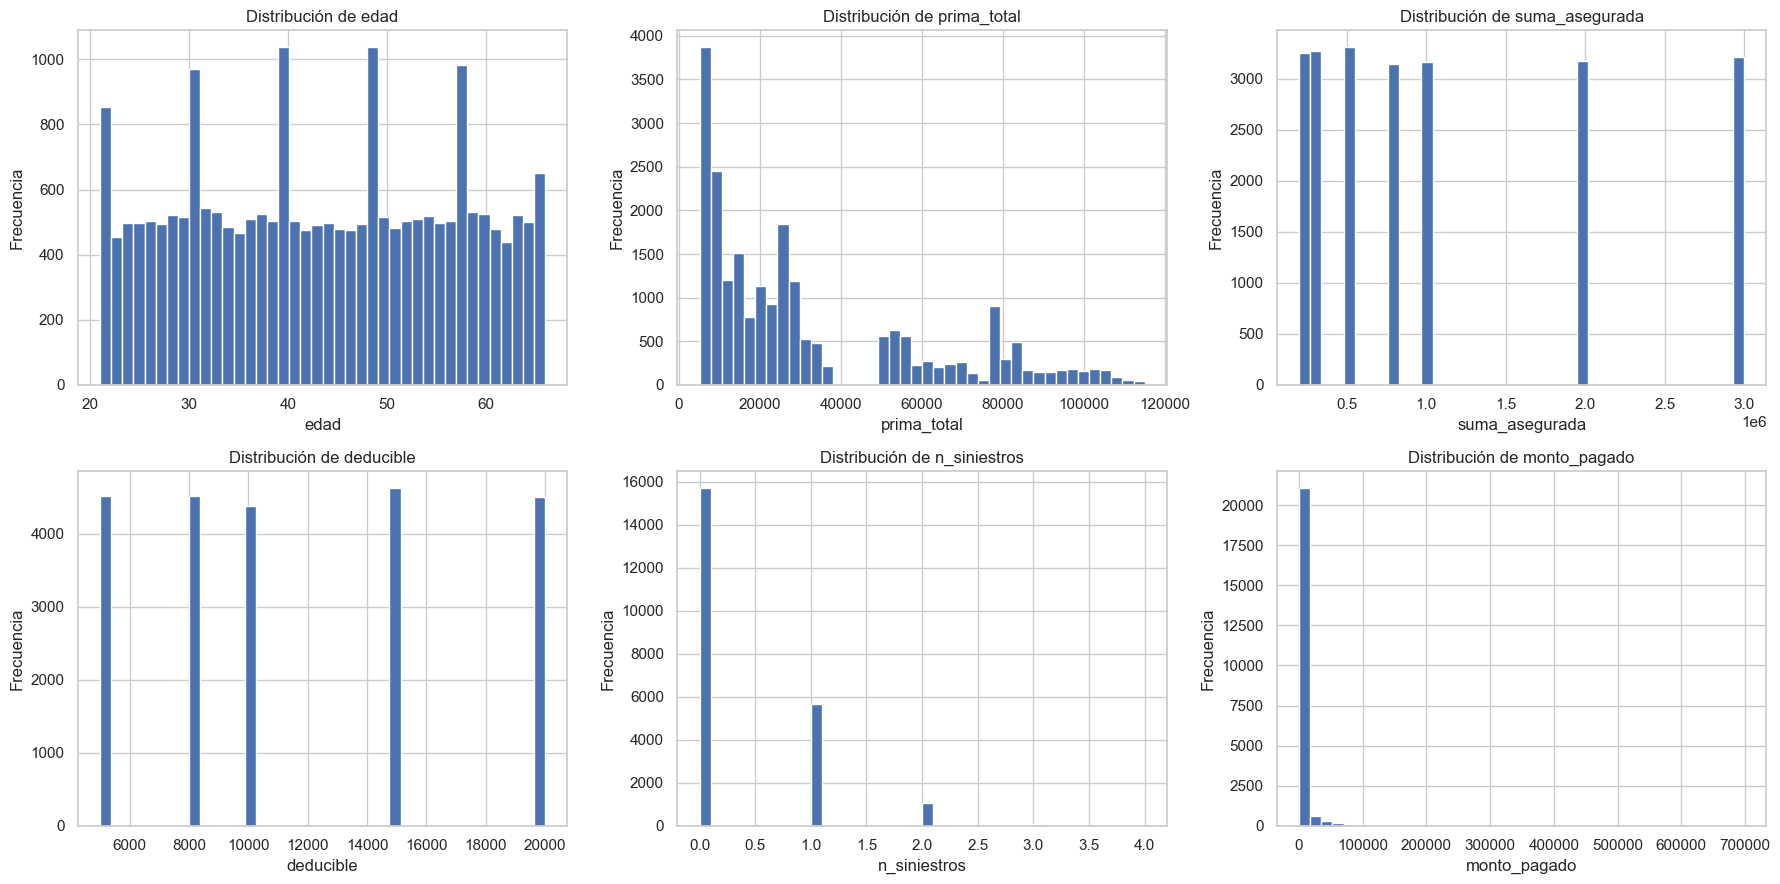

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.ravel()

vars_dist = ["edad", "prima_total", "suma_asegurada", "deducible", "n_siniestros", "monto_pagado"]

for ax, col in zip(axes, vars_dist):
    datos = df_gmm[col].dropna()
    ax.hist(datos, bins=40)
    ax.set_title(f"Distribución de {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

### Interpretación

Podemos observar que la cartera tiene edades distribuidas en varios rangos, sin que todo se concentre en un solo grupo.

También se ve que la prima total está más cargada hacia montos bajos y medios, mientras que sólo una parte menor tiene primas muy altas. Esto nos hace sentido en una cartera de seguros, porque no todas las pólizas tienen el mismo nivel de cobertura o riesgo.

La suma asegurada y el deducible aparecen en valores muy marcados. Esto probablemente se debe a que las pólizas se ofrecen con planes o en paquetes específicos, esto es importante porque esos niveles definen cuánto podría llegar a pagar y qué parte queda a cargo del asegurado.

En la parte de siniestros, la mayoría de registros se concentra en cero o pocos eventos. El monto pagado también está muy concentrado cerca de cero, pero con algunos pagos muy altos.

## 7. Porcentaje de pólizas con siniestro

Ahora calcularemos en qué proporción de pólizas tuvo al menos un siniestro.

In [10]:
porcentaje_siniestro = df_gmm["siniestro_positivo"].mean() * 100

siniestralidad_tabla = (
    df_gmm["siniestro_positivo"]
    .value_counts()
    .rename(index={0: "Sin siniestro", 1: "Con siniestro"})
    .rename_axis("grupo")
    .reset_index(name="registros")
)

siniestralidad_tabla["porcentaje"] = (
    (siniestralidad_tabla["registros"] / len(df_gmm) * 100)
    .round(2)
    .astype(str) + "%"
)

print(f"Porcentaje de pólizas con siniestro: {porcentaje_siniestro:.2f}%")

siniestralidad_tabla

Porcentaje de pólizas con siniestro: 30.38%


,grupo,registros,porcentaje
0,Sin siniestro,15686,69.62%
1,Con siniestro,6845,30.38%


### Interpretación del porcentaje de siniestros

Aproximadamente **30.38%** de las pólizas de GMM tuvieron al menos un siniestro. Esto quiere decir que la mayoría de los asegurados no presentó reclamaciones durante el periodo analizado.

Desde el punto de vista actuarial, este resultado es importante porque confirma que el riesgo no está repartido de manera uniforme: una parte relativamente menor de la cartera concentra los eventos. Por eso no basta con ver promedios generales; también conviene revisar severidad y valores extremos.

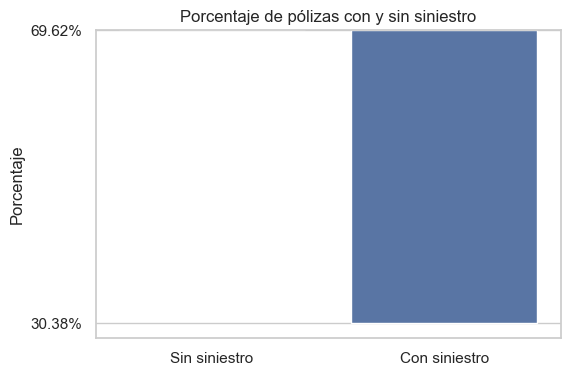

In [11]:
plt.figure(figsize=(6, 4))
sns.barplot(data=siniestralidad_tabla, x="grupo", y="porcentaje")
plt.title("Porcentaje de pólizas con y sin siniestro")
plt.xlabel("")
plt.ylabel("Porcentaje")
plt.show()

### Interpretación

La gráfica deja claro que el grupo sin siniestro es mayor. Esto no significa que el ramo sea necesariamente poco riesgoso, sino que el costo se puede concentrar en menos pólizas.

Este análisis es muy importante, porque un solo siniestro médico grave puede representar un pago alto. Entonces, aunque la frecuencia no sea tan alta, la severidad puede ser el factor que más pese en el resultado final.

## 8. Distribución del monto pagado con transformación logarítmica

Como el monto pagado tiene muchos valores en cero y algunos valores muy altos, revisamos también la versión transformada con logaritmo.

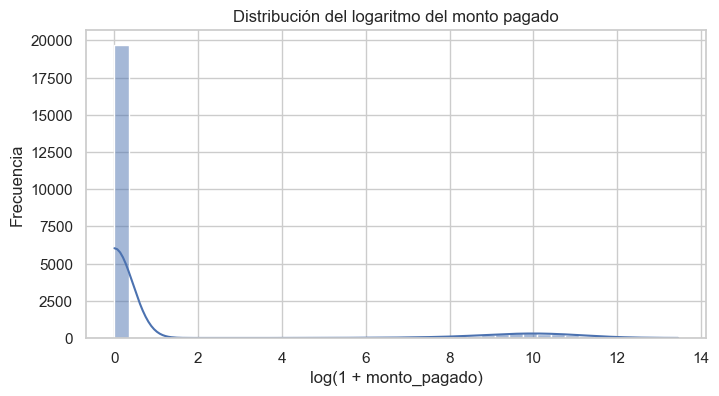

In [12]:
plt.figure(figsize=(8, 4))
sns.histplot(df_gmm["monto_pagado_log"], bins=40, kde=True)
plt.title("Distribución del logaritmo del monto pagado")
plt.xlabel("log(1 + monto_pagado)")
plt.ylabel("Frecuencia")
plt.show()

### Interpretación

Con la transformación logarítmica se alcanza a ver mejor la estructura de los pagos. Sigue existiendo una concentración muy fuerte en cero, pero los montos positivos ya no quedan tan aplastados por los casos extremos.

Esta transformación es útil para modelar, porque los pagos de GMM no se comportan de forma simétrica. Hay muchos registros sin pago y pocos pagos grandes, entonces trabajar con el monto original puede hacer que el modelo se enfoque demasiado en los casos más extremos.

## 9. Correlaciones

Se calcula la matriz de correlación entre las variables numéricas. Esta parte nos ayuda a revisar qué variables se mueven juntas y cuáles podrían estar relacionadas con el monto pagado.

In [13]:
vars_corr = [
    "edad", "num_renovaciones", "suma_asegurada", "deducible",
    "prima_total", "comision_pct", "n_siniestros",
    "monto_reclamado", "monto_pagado", "loss_ratio"
]

# Matriz de correlación
corr = df_gmm[vars_corr].corr()

corr.style.format("{:.2f}") \
    .set_caption("Matriz de correlación entre variables - GMM") \
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "16px"),
                ("font-weight", "bold"),
                ("text-align", "center")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("font-weight", "bold"),
                ("text-align", "center")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("text-align", "center")
            ]
        }
    ])

,edad,num_renovaciones,suma_asegurada,deducible,prima_total,comision_pct,n_siniestros,monto_reclamado,monto_pagado,loss_ratio
edad,1.00,-0.00,0.01,0.01,0.13,-0.01,0.00,0.01,0.00,-0.02
num_renovaciones,-0.00,1.00,-0.00,0.00,-0.00,-0.00,-0.00,-0.01,-0.01,-0.01
suma_asegurada,0.01,-0.00,1.00,-0.00,0.98,-0.00,-0.01,-0.02,-0.02,-0.14
deducible,0.01,0.00,-0.00,1.00,-0.00,0.01,-0.00,-0.01,-0.01,-0.01
prima_total,0.13,-0.00,0.98,-0.00,1.00,-0.00,-0.01,-0.02,-0.02,-0.14
comision_pct,-0.01,-0.00,-0.00,0.01,-0.00,1.00,-0.00,-0.00,-0.00,0.00
n_siniestros,0.00,-0.00,-0.01,-0.00,-0.01,-0.00,1.00,0.60,0.35,0.41
monto_reclamado,0.01,-0.01,-0.02,-0.01,-0.02,-0.00,0.60,1.00,0.66,0.51
monto_pagado,0.00,-0.01,-0.02,-0.01,-0.02,-0.00,0.35,0.66,1.00,0.75
loss_ratio,-0.02,-0.01,-0.14,-0.01,-0.14,0.00,0.41,0.51,0.75,1.00


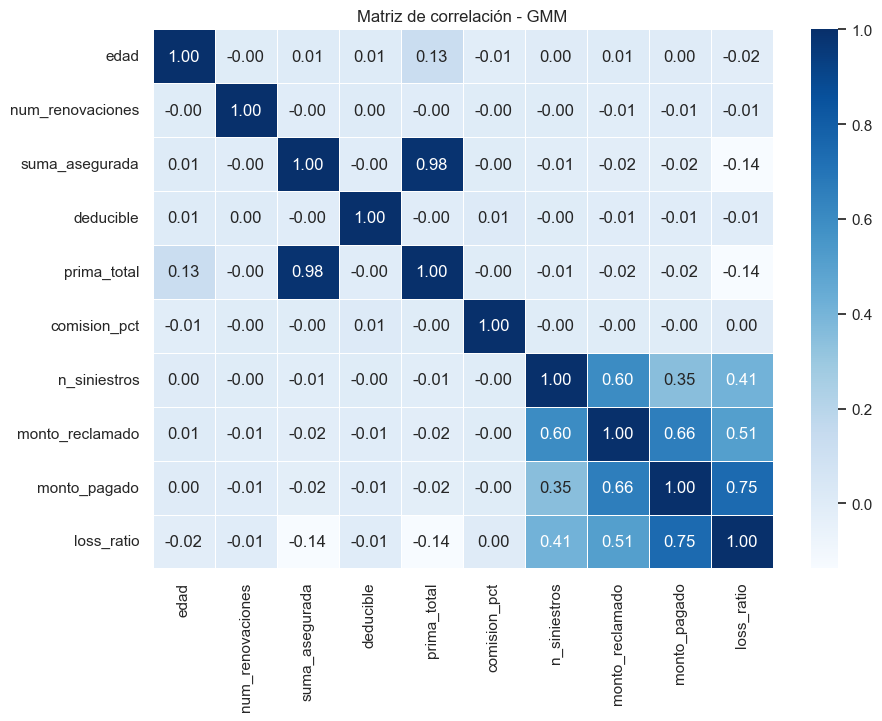

In [14]:
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues", linewidths=0.5)
plt.title("Matriz de correlación - GMM")
plt.show()

### Interpretación

La correlación más alta con `monto_pagado` aparece con `loss_ratio`, `monto_reclamado` y `n_siniestros`. Esto era esperable porque son variables directamente relacionadas con la experiencia de siniestros.

En cambio, variables como edad, prima total, suma asegurada o deducible no muestran una relación lineal fuerte con el monto pagado. 

## 10. Detección de valores atípicos

Nuestro objetivo no es eliminar datos automáticamente, sino identificar qué variables tienen observaciones alejadas del comportamiento central.

In [15]:
def detectar_outliers_iqr(dataframe, columna):
    q1 = dataframe[columna].quantile(0.25)
    q3 = dataframe[columna].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    
    outliers = dataframe[
        (dataframe[columna] < limite_inferior) | 
        (dataframe[columna] > limite_superior)
    ]
    
    return len(outliers), len(outliers) / len(dataframe) * 100, limite_inferior, limite_superior


resumen_outliers = []

for col in [
    "edad", "prima_total", "suma_asegurada", "deducible",
    "n_siniestros", "monto_pagado", "loss_ratio"
]:
    
    n_out, pct_out, lim_inf, lim_sup = detectar_outliers_iqr(df_gmm, col)
    
    resumen_outliers.append({
        "variable": col,
        "outliers": n_out,
        "porcentaje": pct_out,
        "limite_inferior": lim_inf,
        "limite_superior": lim_sup
    })


resumen_outliers = pd.DataFrame(resumen_outliers)


resumen_outliers.style.format({
    "outliers": "{:,.0f}",
    "porcentaje": "{:.2f}%",
    "limite_inferior": "{:,.2f}",
    "limite_superior": "{:,.2f}"
}) \
.set_caption("Detección de valores atípicos mediante método IQR - GMM") \
.set_table_styles([
    {
        "selector": "caption",
        "props": [
            ("font-size", "16px"),
            ("font-weight", "bold"),
            ("text-align", "center")
        ]
    },
    {
        "selector": "th",
        "props": [
            ("font-weight", "bold"),
            ("text-align", "center")
        ]
    },
    {
        "selector": "td",
        "props": [
            ("text-align", "center")
        ]
    }
])

,variable,outliers,porcentaje,limite_inferior,limite_superior
0,edad,0,0.00%,-1.00,87.00
1,prima_total,0,0.00%,"-55,123.20","117,187.84"
2,suma_asegurada,0,0.00%,"-2,250,000.00","4,550,000.00"
3,deducible,0,0.00%,"-2,500.00","25,500.00"
4,n_siniestros,121,0.54%,-1.50,2.50
5,monto_pagado,"2,813",12.49%,0.00,0.00
6,loss_ratio,"2,813",12.49%,0.00,0.00


### Interpretación de los valores atípicos

Los valores atípicos se concentran principalmente en `monto_pagado` y `loss_ratio`, con alrededor de **12.49%** de observaciones marcadas como atípicas. Esto tiene sentido porque los pagos de siniestros no suelen distribuirse de forma pareja: muchos son cero o bajos, pero algunos eventos pueden ser muy costosos.

En este caso no conviene borrar esos registros sólo por ser atípicos, porque en GMM justamente los casos extremos son parte del riesgo que debe analizarse. Más bien debemos tratarlos con cuidado, usando transformaciones o modelos que no dependan únicamente del promedio.

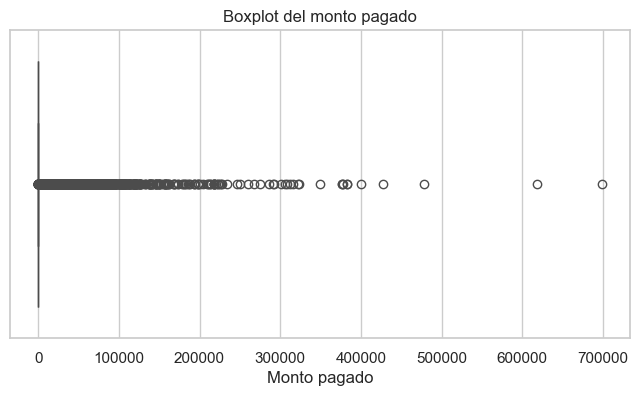

In [16]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_gmm["monto_pagado"])
plt.title("Boxplot del monto pagado")
plt.xlabel("Monto pagado")
plt.show()

### Interpretación boxplot del monto pagado

El boxplot muestra muchos puntos alejados del cuerpo principal de la distribución. Estos puntos representan pagos más altos que el resto de la cartera.

No sólo importa cuántos siniestros ocurren, sino cuánto puede costar cada uno. Los pagos extremos pueden afectar reservas, tarifas y análisis de rentabilidad, por lo que deben considerarse en la interpretación del modelo.

## 11. Regresión Lineal Simple

En esta sección y la siguiente se aborda la implementación del modelo de regresión lineal para la estimación de la **prima_neta** en el ramo de Gastos Médicos Mayores. Primero se desarrollará un modelo de regresión lineal simple y después se extenderá a un modelo de regresión lineal múltiple.

Para ambos modelos utilizaremos la partición de datos 80% entrenamiento, 20% prueba y una semilla de aleatoriedad (`SEED = 20260707`).

El objetivo del modelo de regresion lineal simple es aislar y evaluar el impacto individual de la variable **suma_asegurada**. La suma asegurada representa el límite máximo de responsabilidad que asume la compañía ante un siniestro. Debido a esto, la hipótesis es que existe una relación directa y positiva: a mayor límite de cobertura solicitado por el cliente, mayor será el riesgo asumido por la aseguradora y, en consecuencia, mayor será el costo de la **prima_neta**.

In [17]:
SEED  = 20260707

## PREPARACIÓN DEL CONJUNTO DE DATOS

# Definimos el target y las variables features
TARGET = 'prima_neta'
features_simples = ['suma_asegurada']

X_raw = df_gmm[features_simples]
y = df_gmm[TARGET]

X = pd.get_dummies(X_raw, drop_first=True)
print(f"Features tras OHE: {X.shape[1]} columnas")
print(f"Ejemplos de nuevas columnas: {list(X.columns[:5])} ...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)
print(f"\nTrain: {X_train.shape[0]:,} filas | Test: {X_test.shape[0]:,} filas")

## ENTRENAMIENTO DEL MODELO

modelo = LinearRegression()
modelo.fit(X_train, y_train)

y_pred_train = modelo.predict(X_train)
y_pred_test  = modelo.predict(X_test)

# Métricas en train y test
def _metricas(y_true: pd.Series, y_pred: np.ndarray, nombre: str) -> dict:
    """Calcula RMSE, MAE y R² para un conjunto dado."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return {"Conjunto": nombre, "RMSE (MXN)": f"{rmse:,.0f}",
            "MAE (MXN)": f"{mae:,.0f}", "R²": f"{r2:.4f}"}

metricas = pd.DataFrame([
    _metricas(y_train, y_pred_train, "Train (simple)"),
    _metricas(y_test,  y_pred_test,  "Test (simple)"),
])
print ("\n=======================================")
print("Métricas de evaluación:")
print(metricas.to_string(index=False))

# Tabla de coeficientes
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coeficiente (MXN)": modelo.coef_,
}).sort_values("Coeficiente (MXN)", key=abs, ascending=False)

print ("\n=======================================")
print(f"Intercepto β₀ = {modelo.intercept_:,.2f} MXN")
print()
print("Coeficiente:")
print(coef_df.to_string(index=False))


Features tras OHE: 1 columnas
Ejemplos de nuevas columnas: ['suma_asegurada'] ...

Train: 18,024 filas | Test: 4,507 filas

Métricas de evaluación:
      Conjunto RMSE (MXN) MAE (MXN)     R²
Train (simple)      5,479     3,048 0.9452
 Test (simple)      5,213     2,967 0.9510

Intercepto β₀ = 368.78 MXN

Coeficiente:
       Feature  Coeficiente (MXN)
suma_asegurada               0.02


### Conclusiones: Regresión Lineal Simple

Al analizar los resultados obtenidos mediante el modelo de regresión lineal simple, donde se utilizó únicamente la **suma_asegurada** como variable predictora para estimar la **prima_neta**, observamos que el modelo obtuvo una $R^2$ de 0.9510 en el conjunto de prueba (Test). Esto demuestra estadísticamente que la suma asegurada por sí sola es capaz de explicar el 95.10% de la variabilidad en el costo de la prima neta. Además se encontró consistencia entre los conjuntos de entrenamiento y prueba. Las métricas en Test ($R^2 = 0.9510$, $RMSE = 5,213$) son ligeramente superiores a las de Train ($R^2 = 0.9452$, $RMSE = 5,479$). Esto comprueba que el modelo no sufre de sobreajuste.

**Interpretación de los Coeficientes:**
   * **Intercepto ($\beta_0 = 368.78$ MXN):** Representa teóricamente la prima neta base o el costo fijo del seguro si la suma asegurada fuese cero.
   * **Coeficiente ($\beta_1 = 0.02$ MXN):** El peso asignado a la variable indica que *por cada $100 pesos de incremento en la Suma Asegurada contratada, la prima neta se eleva en exactamente $2.00 pesos netos*.

## 12. Regresión Lineal Multiple

A pesar de que el modelo de regresión lineal simple demostró que la suma asegurada es capaz de explicar el 95.10% de la variabilidad de la prima neta, es posible refinar la estimación incorporando las características demográficas y el nivel de exposición del asegurado. Por ello, en esta sección implementaremos un modelo de **regresión lineal múltiple**.

Este nuevo enfoque incorporará variables numéricas continuas (`edad` y `suma_asegurada`) junto con variables categóricas (`sexo`, `plan`, `ocupacion` y `region` geográfica). Nuesta elección de estas *features* se fundamenta en la naturaleza del ramo de Gastos Médicos Mayores, donde factores como el envejecimiento, las condiciones del entorno laboral (ocupación) y los costos hospitalarios (plan y region) determinan de forma directa la siniestralidad.

Dado que las variables cualitativas no pueden ingresar directamente al estimador lineal, aplicaremos la técnica de **One-Hot Encoding (OHE)** mediante `pd.get_dummies(..., drop_first=True)`. Al omitir la primera categoría de cada variable, evitamos multicolinealidad perfecta y garantizamos que los coeficientes resultantes ($\beta_i$) sean estables e interpretables directamente en pesos mexicanos (MXN).

Features tras OHE: 47 columnas
Ejemplos de nuevas columnas: ['edad', 'suma_asegurada', 'sexo_M', 'plan_20 anios', 'plan_Amplia'] ...

Train: 18,024 filas | Test: 4,507 filas

Métricas de evaluación:
Conjunto RMSE (MXN) MAE (MXN)     R²
   Train      4,680     2,394 0.9600
    Test      4,354     2,337 0.9658

Intercepto β₀ = -9,082.45 MXN

Coeficientes más grandes en valor absoluto (top 15):
                Feature  Coeficiente (MXN)
       ocupacion_Medico            -412.97
     ocupacion_Jubilado            -329.88
        region_Veracruz             228.25
                   edad             219.09
    ocupacion_Ingeniero             217.46
          region_Puebla            -214.90
   ocupacion_Arquitecto             189.51
         region_Jalisco             186.71
  ocupacion_Ama de casa             183.29
       region_Queretaro            -170.41
         region_Yucatan            -157.70
      ocupacion_Tecnico             155.30
          region_Sonora            -145.08
ocu

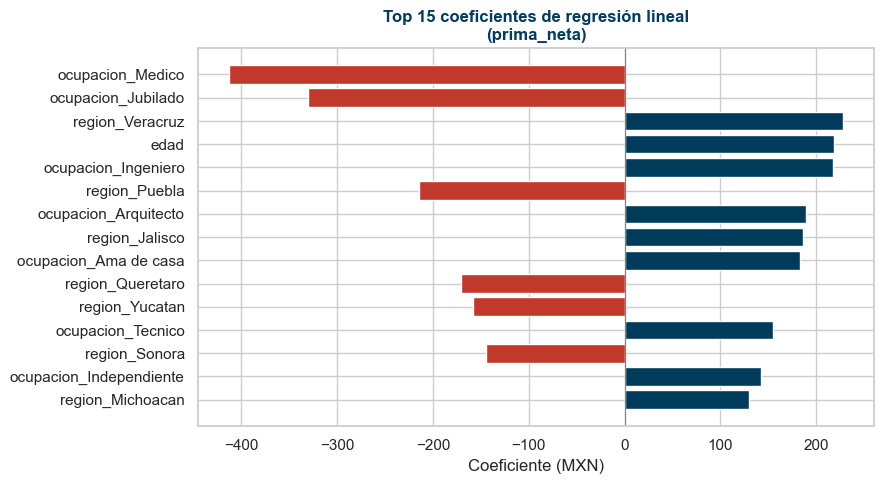

In [18]:
SEED  = 20260707

## PREPARACIÓN DEL CONJUNTO DE DATOS

# Definimos el target y las variables features
TARGET = 'prima_neta'
features_categoricas = ['sexo', 'plan', 'ocupacion', 'region']
features_continuas = ['edad', 'suma_asegurada']

X_raw = df_gmm[features_categoricas + features_continuas]
y = df_gmm[TARGET]

X = pd.get_dummies(X_raw, columns=features_categoricas, drop_first=True)
print(f"Features tras OHE: {X.shape[1]} columnas")
print(f"Ejemplos de nuevas columnas: {list(X.columns[:5])} ...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)
print(f"\nTrain: {X_train.shape[0]:,} filas | Test: {X_test.shape[0]:,} filas")

## ENTRENAMIENTO DEL MODELO

modelo = LinearRegression()
modelo.fit(X_train, y_train)

y_pred_train = modelo.predict(X_train)
y_pred_test  = modelo.predict(X_test)

# Métricas en train y test
def _metricas(y_true: pd.Series, y_pred: np.ndarray, nombre: str) -> dict:
    """Calcula RMSE, MAE y R² para un conjunto dado."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return {"Conjunto": nombre, "RMSE (MXN)": f"{rmse:,.0f}",
            "MAE (MXN)": f"{mae:,.0f}", "R²": f"{r2:.4f}"}

metricas = pd.DataFrame([
    _metricas(y_train, y_pred_train, "Train"),
    _metricas(y_test,  y_pred_test,  "Test"),
])
print ("\n=======================================")
print("Métricas de evaluación:")
print(metricas.to_string(index=False))

# Tabla de coeficientes
print ("\n=======================================")
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coeficiente (MXN)": modelo.coef_,
}).sort_values("Coeficiente (MXN)", key=abs, ascending=False)

print(f"Intercepto β₀ = {modelo.intercept_:,.2f} MXN")
print()
print("Coeficientes más grandes en valor absoluto (top 15):")
print(coef_df.head(15).to_string(index=False))

# Visualización de los 15 coeficientes más importantes
NAVY  = "#003B5C"
GOLD  = "#C8A33A"
RED   = "#C0392B"

top15 = coef_df.head(15).copy()
colores = [RED if c < 0 else NAVY for c in top15["Coeficiente (MXN)"]]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top15["Feature"], top15["Coeficiente (MXN)"], color=colores, edgecolor="white")
ax.axvline(0, color="gray", linewidth=0.8)
ax.set_xlabel("Coeficiente (MXN)")
ax.set_title("Top 15 coeficientes de regresión lineal\n(prima_neta)",
             fontsize=12, fontweight="bold", color=NAVY)
ax.invert_yaxis()
plt.tight_layout()
plt.show()


### Conclusiones: Regresión Lineal Múltiple

Al evaluar el rendimiento y los parámetros estimados por el modelo de regresión lineal múltiple, observamos que la $R^2$ es igual a 0.9658. Esto significa que al combinar las características demográficas y geográficas, el modelo es capaz de explicar el *96.58%* de la variabilidad del costo de la prima neta.

En comparación con el modelo de regresión lineal simple (que arrojó un $R^2 = 0.9510$), esta aproximación múltiple captura un **1.48% adicional** de la variabilidad del riesgo. Dicho incremento demuestra que, aunque la suma asegurada es un factor clave, la adición de variables como la edad, el sexo, la ocupación y la región geográfica es indispensable para mejorar precisión de la estimación.

#### Interpretación de los Coeficientes
Al analizar algunos coeficientes del top 15 con mayor impacto, se observa lo siguiente:

* **Impacto de la Edad ($\beta_{edad} = +219.09$ MXN):** Manteniendo todas las demás variables constantes, *por cada año que envejece el asegurado, el costo de la prima neta se incrementa en $219.09 MXN*. Esto es coherente considerando que se trata del ramo de Gastos Médicos Mayores, donde la siniestralidad aumenta paulatinamente con la edad.
* **Ocupación:** 
  * Las categorías `ocupacion_Medico` ($-412.97 MXN$) y `ocupacion_Jubilado` ($-329.88 MXN$) actúan como factores reductores de la prima. En el caso de los médicos, esto puede atribuirse a un menor costo por prevención, mayor conocimiento de salud o redes de contactos médicos que reducen la severidad de ciertos reclamos.
  * Por el contrario, ocupaciones como `Ingeniero` ($+217.46 MXN$) o `Arquitecto` ($+189.51 MXN$) elevan el costo de la prima, probablemente asociado a riesgos laborales en campo u obras.
* **Región Geográfica:**
  * Vivir en la región de `Veracruz` ($+228.25 MXN$) o `Jalisco` ($+186.71 MXN$) encarece la prima, sugiriendo una mayor frecuencia de siniestros o una inflación más alta en hospitales privados de esas zonas.
  * Por el contrario, regiones como `Puebla` ($-214.90 MXN$) o `Queretaro` ($-170.41 MXN$) disminuyen la prima, lo que denota costos hospitalarios más controlados o menor siniestralidad.

## 13. Regresión polinómica 

La regresión polinómica amplía el modelo lineal mediante la incorporación de potencias e interacciones entre las variables numéricas. En esta sección se conserva como variable objetivo la prima_neta y se utilizan las mismas características de la regresión lineal múltiple: edad, suma_asegurada, sexo, plan, ocupacion y region.

Se comparan modelos de grados 1, 2 y 3. El grado 1 representa la relación lineal de referencia; el grado 2 incorpora términos como edad², suma asegurada² y la interacción edad × suma asegurada; el grado 3 agrega términos cúbicos y nuevas interacciones. Las variables categóricas se codifican mediante One-Hot Encoding, pero no se elevan a potencias.

In [ ]:
SEED = 20260707

TARGET_POLY = "prima_neta"
features_continuas_poly = ["edad","suma_asegurada"]
features_categoricas_poly = ["sexo","plan","ocupacion","region"]

X_poly = df_gmm[features_continuas_poly + features_categoricas_poly].copy()
y_poly = df_gmm[TARGET_POLY].copy()

# División idéntica para todos los grados
X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(
    X_poly,y_poly,test_size=0.20,random_state=SEED
)

print(f"Train: {X_train_poly.shape[0]:,} filas")
print(f"Test:  {X_test_poly.shape[0]:,} filas")

Train: 18,024 filas
Test:  4,507 filas


In [20]:
resultados_poly = []
modelos_poly = {}

for grado in [1, 2, 3]:

    # Transformación de variables numéricas
    pipeline_numerico = Pipeline(steps=[
        ("imputer",SimpleImputer(strategy="median")),
        ("poly",PolynomialFeatures(degree=grado,include_bias=False)),
        ("scaler",StandardScaler())
        ])

    # Transformación de variables categóricas
    pipeline_categorico = Pipeline(steps=[
        ("imputer",SimpleImputer(strategy="most_frequent")),
        ("onehot",OneHotEncoder(handle_unknown="ignore",drop="first"))
    ])

    preprocesamiento_poly = ColumnTransformer(
        transformers=[
            ("num",pipeline_numerico,features_continuas_poly),
            ("cat",pipeline_categorico,features_categoricas_poly)
        ]
    )

    # Pipeline completo
    modelo_poly = Pipeline(steps=[
        ("preprocesamiento",preprocesamiento_poly),
        ("modelo",LinearRegression())
    ])

    # Entrenamiento
    modelo_poly.fit(X_train_poly,y_train_poly)
    y_pred_train_poly = modelo_poly.predict(X_train_poly)
    y_pred_test_poly = modelo_poly.predict(X_test_poly)

    # Métricas de evalucacion
    resultados_poly.append({
        "Modelo": f"Polinómica grado {grado}",
        "RMSE Train (MXN)": np.sqrt(
            mean_squared_error(y_train_poly,y_pred_train_poly)
        ),
        "RMSE Test (MXN)": np.sqrt(
            mean_squared_error(y_test_poly,y_pred_test_poly)
        ),
        "MAE Train (MXN)": mean_absolute_error(y_train_poly,y_pred_train_poly
        ),
        "MAE Test (MXN)": mean_absolute_error(y_test_poly,y_pred_test_poly
        ),
        "R² Train": r2_score(y_train_poly,y_pred_train_poly
        ),
        "R² Test": r2_score(y_test_poly,y_pred_test_poly
        )
    })

    modelos_poly[grado] = modelo_poly

metricas_poly = pd.DataFrame(resultados_poly)

metricas_poly

,Modelo,RMSE Train (MXN),RMSE Test (MXN),MAE Train (MXN),MAE Test (MXN),R² Train,R² Test
0,Polinómica grado 1,"4,680.38","4,354.40","2,394.12","2,337.19",0.96,0.97
1,Polinómica grado 2,"3,859.51","3,448.21","1,155.46","1,121.61",0.97,0.98
2,Polinómica grado 3,"3,754.41","3,320.57",826.22,797.23,0.97,0.98


Notemos que al pasar del grado 1 al 3, el *$RMSE$* y *$MAE$* de prueba disminuye aproximadamente *23%* y *65%* respectivamente, de igual manera el $R^2$ aumenta 


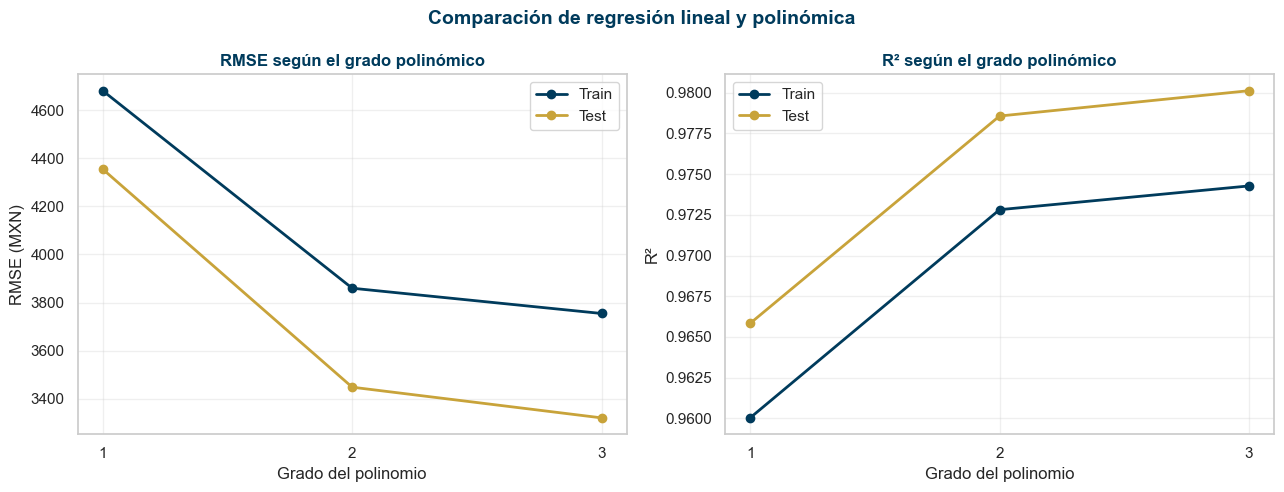

In [21]:
# comparamos las métricas que obtuvimos
NAVY = "#003B5C"
GOLD = "#C8A33A"
RED = "#C0392B"

grados = [1, 2, 3]

fig, axes = plt.subplots(1,2,figsize=(13, 5))

# RMSE
axes[0].plot(grados,metricas_poly["RMSE Train (MXN)"],
    marker="o",linewidth=2,color=NAVY,label="Train"
)

axes[0].plot(grados,metricas_poly["RMSE Test (MXN)"],
    marker="o",linewidth=2,color=GOLD,label="Test"
)

axes[0].set_xticks(grados)
axes[0].set_xlabel("Grado del polinomio")
axes[0].set_ylabel("RMSE (MXN)")
axes[0].set_title("RMSE según el grado polinómico",fontweight="bold",color=NAVY)
axes[0].legend()
axes[0].grid(alpha=0.3)

# R²
axes[1].plot(grados,metricas_poly["R² Train"],
    marker="o",linewidth=2,color=NAVY,label="Train"
)

axes[1].plot(grados,metricas_poly["R² Test"],
    marker="o",linewidth=2,color=GOLD,label="Test"
)

axes[1].set_xticks(grados)
axes[1].set_xlabel("Grado del polinomio")
axes[1].set_ylabel("R²")
axes[1].set_title("R² según el grado polinómico",fontweight="bold",color=NAVY)
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.suptitle("Comparación de regresión lineal y polinómica",fontsize=14,
    fontweight="bold",color=NAVY
)

plt.tight_layout()
plt.show()

Las gráficas confirman que el *$RMSE$* disminuye al aumentar el grado, también la mejora principal ocurre de pasar del modelo lineal al modelo cuadrático

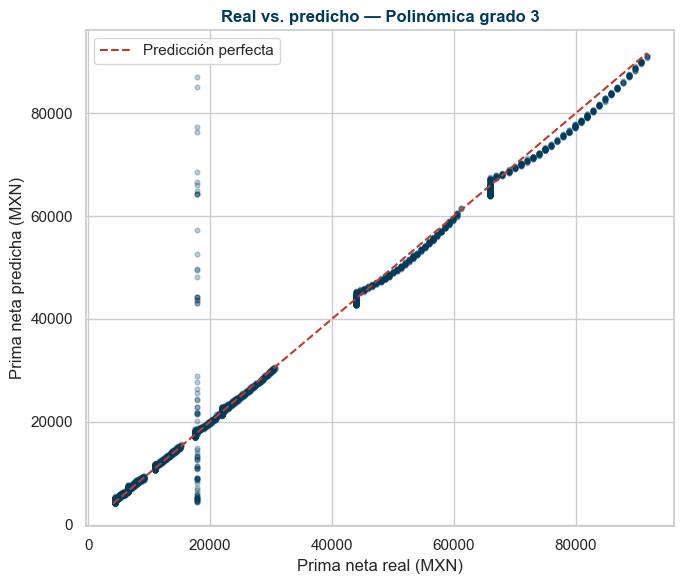

Mejor grado según RMSE de test: 3


In [22]:
# Seleccionar automáticamente el modelo con menor RMSE en test
indice_mejor = metricas_poly["RMSE Test (MXN)"].idxmin()
mejor_grado = indice_mejor + 1
mejor_modelo_poly = modelos_poly[mejor_grado]

y_pred_mejor_poly = mejor_modelo_poly.predict(X_test_poly)

plt.figure(figsize=(7, 6))

plt.scatter(y_test_poly,y_pred_mejor_poly,
    alpha=0.25,s=12,color=NAVY
)

limite_min = min(y_test_poly.min(),y_pred_mejor_poly.min())
limite_max = max(y_test_poly.max(),y_pred_mejor_poly.max())

plt.plot([limite_min, limite_max],[limite_min, limite_max],
    linestyle="--",linewidth=1.5,color=RED,label="Predicción perfecta"
)

plt.xlabel("Prima neta real (MXN)")
plt.ylabel("Prima neta predicha (MXN)")
plt.title(f"Real vs. predicho — Polinómica grado {mejor_grado}",
    fontweight="bold",color=NAVY
)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Mejor grado según RMSE de test: {mejor_grado}")

La gráfica de valores reales contra predichos muestra que la mayoría de las observaciones se encuentra cerca de la línea de predicción perfecta. No obstante, existe un grupo de pólizas con prima real cercana a $18,000 que presenta errores considerablemente mayores. Esto indica que, aunque el modelo explica adecuadamente el comportamiento general de la cartera, todavía existen segmentos o casos atípicos cuya estructura tarifaria no queda completamente representada por las variables y transformaciones utilizadas.

### Conclusiones: Regresión polinómica

Se compararon modelos de regresión polinómica de grados 1, 2 y 3 utilizando como variable objetivo la prima neta y las mismas variables explicativas empleadas en la regresión lineal múltiple. Los resultados muestran que incorporar términos polinómicos mejora la capacidad predictiva del modelo respecto al ajuste lineal.

El modelo de grado 3 obtuvo el mejor desempeño, presentando el menor RMSE y MAE tanto en entrenamiento como en prueba, además del mayor coeficiente de determinación ($R^2$). Esto indica que existen relaciones no lineales entre variables como la edad y la suma asegurada con respecto a la prima neta, las cuales no son capturadas completamente mediante un modelo lineal.

Asimismo, la diferencia entre las métricas de entrenamiento y prueba es pequeña, por lo que no se observa evidencia importante de sobreajuste. Esto sugiere que el modelo mantiene una buena capacidad de generalización sobre datos no utilizados durante el entrenamiento.

## 14. Regresión logística
La regresión logística se utiliza para modelar una variable objetivo binaria. En este caso, se busca estimar la probabilidad de que una póliza de GMM presente al menos un siniestro durante su vigencia.

La variable siniestro_positivo toma el valor 1 cuando n_siniestros > 0 y 0 en caso contrario. Se emplean las mismas variables explicativas utilizadas en la regresión lineal múltiple para analizar si las características demográficas, geográficas y de cobertura permiten distinguir las pólizas con y sin siniestro.

In [23]:
SEED = 20260707

features_continuas_log = ["edad","suma_asegurada"]
features_categoricas_log = [ "sexo","plan","ocupacion","region"]

X_log = df_gmm[features_continuas_log + features_categoricas_log].copy()
y_log = df_gmm["siniestro_positivo"].copy()

print("Distribución de la variable objetivo:")
print(y_log.value_counts()
    .rename(index={0: "Sin siniestro", 1: "Con siniestro"})
)

print("\nPorcentajes:")
print(y_log.value_counts(normalize=True)
    .rename(index={0: "Sin siniestro", 1: "Con siniestro"})
    .mul(100).round(2)
)

Distribución de la variable objetivo:
siniestro_positivo
Sin siniestro    15686
Con siniestro     6845
Name: count, dtype: int64

Porcentajes:
siniestro_positivo
Sin siniestro   69.62
Con siniestro   30.38
Name: proportion, dtype: float64


In [24]:
preprocesamiento_log = ColumnTransformer(
    transformers=[
        ("num",Pipeline(steps=[
                ("imputer",SimpleImputer(strategy="median")),
                ("scaler",StandardScaler())
            ]),
            features_continuas_log),
        ("cat",Pipeline(steps=[
                ("imputer",SimpleImputer(strategy="most_frequent")),
                ("onehot",OneHotEncoder(handle_unknown="ignore",drop="first"))
            ]),
            features_categoricas_log
        )
    ]
)

X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X_log,y_log,test_size=0.20,random_state=SEED,stratify=y_log
)

print(f"Train: {X_train_log.shape[0]:,} filas")
print(f"Test:  {X_test_log.shape[0]:,} filas")

Train: 18,024 filas
Test:  4,507 filas


In [25]:
modelo_logistico = Pipeline(steps=[
    ("preprocesamiento",preprocesamiento_log),
    ("modelo",LogisticRegression(max_iter=2000,class_weight="balanced",random_state=SEED))
])

modelo_logistico.fit(X_train_log,y_train_log)

# Clasificaciones 0/1
y_pred_log = modelo_logistico.predict(X_test_log)

# Probabilidad estimada de la clase 1
y_prob_log = modelo_logistico.predict_proba(X_test_log)[:, 1]

In [26]:
metricas_log = pd.DataFrame({
    "Modelo": ["Regresión logística"],
    "Accuracy": [accuracy_score(y_test_log,y_pred_log)],
    "Precision": [precision_score(y_test_log,y_pred_log,zero_division=0)],
    "Recall": [recall_score(y_test_log,y_pred_log,zero_division=0)],
    "F1": [f1_score(y_test_log,y_pred_log,zero_division=0)],
    "ROC-AUC": [roc_auc_score(y_test_log,y_prob_log)]
})

metricas_log.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1": "{:.4f}",
    "ROC-AUC": "{:.4f}"
}) \
.set_caption("Resultados del modelo de Regresión Logística") \
.set_table_styles([
    {"selector": "caption",
        "props": [
            ("font-size", "16px"),
            ("font-weight", "bold"),
            ("text-align", "center")
        ]
    },
    {"selector": "th",
        "props": [
            ("font-weight", "bold"),
            ("text-align", "center")
        ]
    },
    {"selector": "td",
        "props": [
            ("text-align", "center")
        ]
    }
])

,Modelo,Accuracy,Precision,Recall,F1,ROC-AUC
0,Regresión logística,0.5192,0.3127,0.4865,0.3807,0.5104


El modelo obtuvo un *$Accuracy$* de $0.5192$, lo que indica que clasificó correctamente aproximadamente el *52%* de las pólizas del conjunto de prueba. Este valor es relativamente bajo y muestra que el modelo tiene dificultades para diferenciar correctamente entre pólizas con y sin siniestro.

El *$Recall$* de $0.4865$ indica que el modelo logró identificar aproximadamente el *48.7%* de las pólizas que efectivamente presentaron un siniestro, dejando sin detectar poco más de la mitad de los eventos reales.

In [ ]:
# Matriz de confusión
matriz_log = confusion_matrix(y_test_log,y_pred_log)

matriz_log_df = pd.DataFrame(matriz_log,
    index=["Real: Sin siniestro","Real: Con siniestro"],
    columns=["Predicción: Sin siniestro","Predicción: Con siniestro"]
)

matriz_log_df.style.format("{:,.0f}") \
.set_caption("Matriz de confusión - Regresión Logística") \
.set_table_styles([
    {"selector": "caption",
        "props": [
            ("font-size", "16px"),
            ("font-weight", "bold"),
            ("text-align", "center")
        ]
    },
    {"selector": "th",
        "props": [
            ("font-weight", "bold"),
            ("text-align", "center")
        ]
    },
    {"selector": "td",
        "props": [
            ("text-align", "center")
        ]
    }
])

,Predicción: Sin siniestro,Predicción: Con siniestro
Real: Sin siniestro,"1,674","1,464"
Real: Con siniestro,703,666


El modelo clasificó correctamente $1,674$ pólizas sin siniestro (verdaderos negativos) y $666$ pólizas con siniestro (verdaderos positivos). El elevado número de falsos positivos explica la baja Precision obtenida, ya que muchas pólizas fueron clasificadas como riesgosas sin llegar a presentar un evento. Por otro lado, los $703$ falsos negativos muestran que el modelo dejó sin identificar una cantidad importante de siniestros reales.

Los falsos negativos suelen representar el tipo de error más relevante, ya que corresponden a riesgos que no fueron anticipados y que posteriormente pueden generar pérdidas económicas para la aseguradora. No obstante, un exceso de falsos positivos también puede provocar una sobreestimación del riesgo y decisiones de suscripción o tarificación innecesariamente conservadoras.

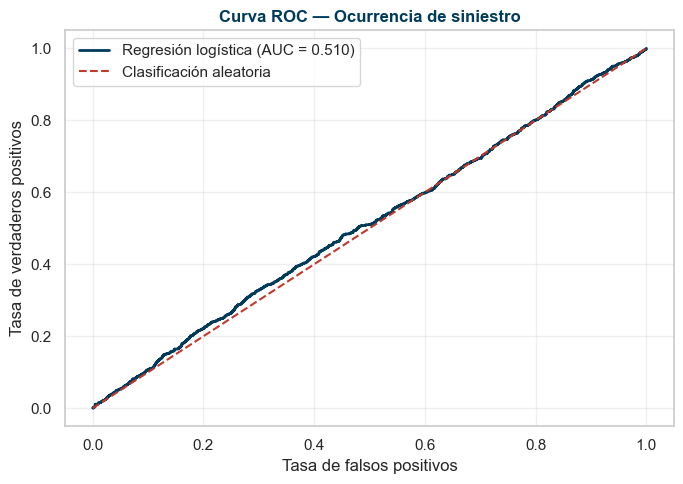

In [30]:
# Curva ROC
fpr, tpr, umbrales = roc_curve(y_test_log,y_prob_log)
auc_log = roc_auc_score(y_test_log,y_prob_log)
plt.figure(figsize=(7, 5))

plt.plot(fpr,tpr,linewidth=2,color=NAVY,label=f"Regresión logística (AUC = {auc_log:.3f})")

plt.plot([0, 1],[0, 1],linestyle="--",
    color=RED,label="Clasificación aleatoria"
)

plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC — Ocurrencia de siniestro",fontweight="bold",color=NAVY)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

El área bajo la curva *(AUC = 0.5104)* es muy cercana a $0.50$, lo que indica que el modelo posee una capacidad muy limitada para distinguir entre pólizas con y sin siniestro.

In [31]:
# Nombres finales después del preprocesamiento
nombres_log = (modelo_logistico.named_steps["preprocesamiento"].get_feature_names_out())
coeficientes_log = (modelo_logistico.named_steps["modelo"].coef_[0])

tabla_coef_log = pd.DataFrame({
    "Feature": nombres_log,
    "Coeficiente log-odds": coeficientes_log,
    "Odds ratio": np.exp(coeficientes_log)
})

tabla_coef_log["Impacto absoluto"] = (tabla_coef_log["Coeficiente log-odds"].abs())
tabla_coef_log = tabla_coef_log.sort_values("Impacto absoluto",ascending=False)
tabla_coef_log.head(15).style.format({
    "Coeficiente log-odds": "{:.4f}",
    "Odds ratio": "{:.4f}",
    "Impacto absoluto": "{:.4f}"
}).set_caption("Principales coeficientes de la Regresión Logística")

,Feature,Coeficiente log-odds,Odds ratio,Impacto absoluto
23,cat__ocupacion_Medico,0.1306,1.1396,0.1306
35,cat__region_Sonora,0.1147,1.1215,0.1147
32,cat__region_Nuevo Leon,0.0910,1.0953,0.0910
6,cat__ocupacion_Administrativo,0.0804,1.0837,0.0804
21,cat__ocupacion_Jubilado,-0.0776,0.9253,0.0776
38,cat__region_Yucatan,-0.0695,0.9329,0.0695
8,cat__ocupacion_Analista,-0.0687,0.9336,0.0687
9,cat__ocupacion_Arquitecto,0.0653,1.0675,0.0653
36,cat__region_Tamaulipas,-0.0579,0.9437,0.0579
29,cat__region_Guanajuato,0.0569,1.0585,0.0569


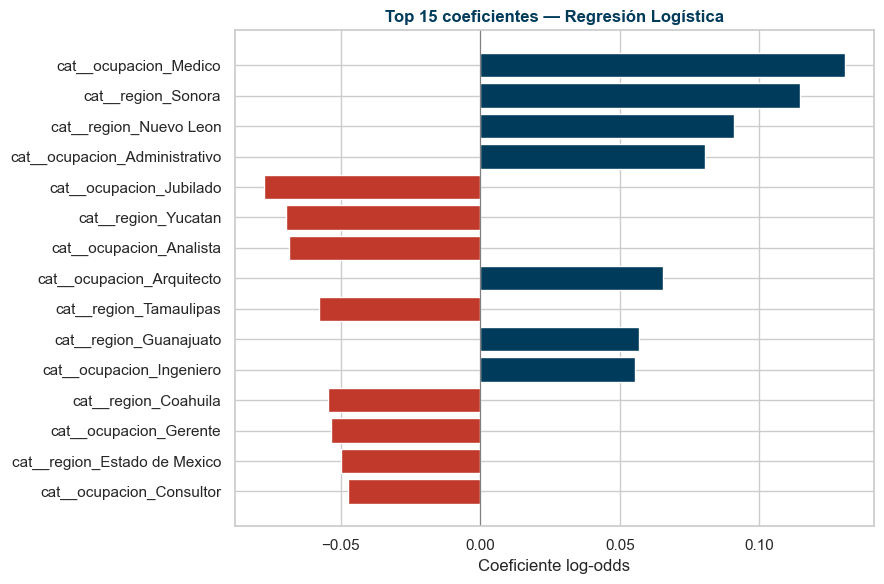

In [33]:
top15_log = tabla_coef_log.head(15).copy()

colores_log = [RED if coef < 0 else NAVY for coef in top15_log["Coeficiente log-odds"]]

plt.figure(figsize=(9, 6))

plt.barh(top15_log["Feature"],top15_log["Coeficiente log-odds"],
    color=colores_log,edgecolor="white"
)

plt.axvline(0,color="gray",linewidth=0.8)
plt.xlabel("Coeficiente log-odds")
plt.title("Top 15 coeficientes — Regresión Logística",fontsize=12,
    fontweight="bold",color=NAVY
)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Conclusiones: Regresion logística

La regresión logística permitió modelar la probabilidad de ocurrencia de un siniestro utilizando información disponible al momento de la contratación de la póliza. Sin embargo, las métricas obtenidas muestran que el modelo presenta una capacidad predictiva limitada. Tanto el *$Accuracy$* (51.9%) como el *$ROC-AUC$* (0.5104) indican que las variables utilizadas no son suficientes para distinguir de manera confiable entre pólizas con y sin siniestro.

Asimismo, el bajo valor de Precision evidencia que una proporción considerable de las pólizas clasificadas como riesgosas no presentó siniestros, mientras que el Recall inferior al *50%* indica que el modelo deja sin identificar una parte importante de los eventos reales.

## 16. Comentarios

1. Se seleccionó el ramo **GMM** porque es el que tiene mayor número de registros dentro de la base y porque actuarialmente permite analizar frecuencia y severidad de siniestros.

2. En el análisis exploratorio se observó que muchas pólizas no presentan siniestros, pero existen pagos altos que generan una cola importante en la distribución de `monto_pagado`. Esto es consistente con el comportamiento esperado en Gastos Médicos Mayores.

3. Las estadísticas descriptivas y los boxplots muestran que los valores atípicos no necesariamente son errores. En este ramo pueden representar casos médicos de alta severidad, por lo que deben analizarse y no eliminarse automáticamente.

4. La matriz de correlación indica que las variables más relacionadas con `monto_pagado` son las que ya están conectadas directamente con siniestros, como `monto_reclamado`, `n_siniestros` y `loss_ratio`. Las variables generales de póliza muestran relaciones más débiles.

5. En la parte de regresión se compararon modelos lineales y polinómicos para estimar la prima neta. La regresión polinómica obtuvo el mejor desempeño, evidenciando que existen relaciones no lineales entre las variables explicativas y la variable objetivo. En particular, el modelo de grado 3 presentó el menor error de predicción y el mayor coeficiente de determinación, manteniendo un comportamiento estable tanto en entrenamiento como en prueba.

6. En conjunto, los resultados muestran que los modelos de Machine Learning constituyen herramientas valiosas para apoyar la toma de decisiones actuariales. Mientras que los modelos lineales ofrecen interpretabilidad y facilidad de implementación, modelos más flexibles como la regresión polinómica permiten capturar relaciones más complejas entre las variables, mejorando la capacidad predictiva cuando la naturaleza del problema así lo requiere.